# HapSleep — PoC multi-wearable con datos reales de otros relojes · **exploratorio**

Con los datasets descargados a mano (carpeta `datasets/`) se hacen **dos comprobaciones**:

1. **Xiaomi (Mi Band, datos reales).** Se escribe un adaptador para el formato real de exportación (JSON por evento), se
   convierte a las variables diarias del modelo y se pasa por la capa de estandarización del notebook anterior
   (`POC_Multiwearable.ipynb`). Sirve para comprobar (a) qué variables existen de verdad en un Xiaomi, (b) que la capa
   funciona con un formato real y (c) cómo se comparan sus valores con los de LifeSnaps.
2. **MMASH (PSQI real).** Con 22 hombres jóvenes: ¿el PSQI se relaciona con las variables de sueño medidas por
   actigrafía (duración, eficiencia, despertares)? Es una comprobación de sentido, no una validación.

**Límites que hay que tener presentes**
- El dataset de Xiaomi tiene **4 usuarios**: no se puede entrenar ni validar nada con él. Sus resultados son descriptivos.
- MMASH tiene **22 hombres y una noche** por persona, con actígrafo de investigación (no es un reloj comercial), y el PSQI
  cubre el último mes, no esa noche.
- El Garmin descargado se **descartó** (alumnos de colegio, mediana de 4.5 noches, sin pulso en reposo ni HRV) y Walch/Apple
  no se usa aquí. Detalles en las fichas `FUENTE.md`.
- El modelo sigue entrenado con LifeSnaps (Fitbit) y el proxy; aquí solo se le pasan datos de otra marca para probar la capa.

In [1]:
import sys, json, glob, os, warnings
from pathlib import Path
try:
    sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

XIAOMI_CSV = Path("datasets/xiaomi/group_health_sleep_screen/GroupHealth_SleepScreen.csv")
MMASH_ROOT = Path(glob.glob("datasets/otros/mmash_polar_actigraph/multilevel*")[0])
LIFESNAPS = Path("../POC1/data/daily_fitbit_sema_df_unprocessed.csv")
TZ = "Europe/Amsterdam"   # supuesto: dataset de TU/e; coincide con los campos "timezone" 4 (UTC+1) y 8 (UTC+2, x15 min)
print("Archivos encontrados:", XIAOMI_CSV.exists(), MMASH_ROOT.exists(), LIFESNAPS.exists())

Archivos encontrados: True True True


## Parte 1 — Xiaomi (Mi Band) con datos reales

El CSV es un registro de eventos: cada fila trae en `Value` un JSON, y `Key` dice de qué tipo es. Claves relevantes y su
contenido (verificado al abrir el archivo):

| Clave | Contenido |
|---|---|
| `sleep` | Una sesión de sueño: `duration` (minutos dormido = profundo + ligero + REM), `sleep_awake_duration` (minutos despierto), `bedtime` y `wake_up_time` (hora de acostarse y levantarse), a veces pulso y SpO2 medios |
| `resting_heart_rate` | Un valor de pulso en reposo por día |
| `steps` | Pasos por minuto |
| `spo2` | Saturación de oxígeno (varias mediciones al día) |

**Reglas del adaptador (lo que se aprendió al mirar datos reales):**
- Hay **siestas** (sesiones cortas). Se considera siesta una sesión de menos de 90 minutos, y por cada día se conserva la
  sesión más larga como "sueño principal".
- El día se asigna con la hora **local** de levantarse (se supone la zona de Ámsterdam).
- El Xiaomi **no entrega eficiencia**: se calcula como `dormido / tiempo en cama × 100`, con el tiempo en cama = hora de
  levantarse menos hora de acostarse.
- Los pasos diarios son la suma de los minutos registrados: si el reloj no se usó parte del día, queda por debajo.
- **El pulso en reposo casi nunca viene** (solo un usuario de cuatro trae la clave). El reloj sí graba pulso minuto a minuto,
  así que el adaptador lo **deriva**: percentil bajo de las lecturas durante la sesión de sueño (mínimo 30 lecturas). Se
  compara contra el valor del dispositivo en los días donde existen ambos, para elegir la definición y medir el sesgo.

In [2]:
raw = pd.read_csv(XIAOMI_CSV, low_memory=False)
raw["j"] = raw["Value"].apply(lambda v: json.loads(v) if isinstance(v, str) and v.startswith("{") else {})


def local_date(epoch_s):
    return pd.to_datetime(epoch_s, unit="s", utc=True).dt.tz_convert(TZ).dt.tz_localize(None).dt.normalize()


def key_rows(key):
    return raw[raw.Key == key].copy()


# --- sueño: una fila por sesión ---
s = key_rows("sleep")
s["asleep"] = s.j.apply(lambda j: j.get("duration"))
s["awake"] = s.j.apply(lambda j: j.get("sleep_awake_duration", 0))
s["bed"] = s.j.apply(lambda j: j.get("bedtime"))
s["wake"] = s.j.apply(lambda j: j.get("wake_up_time"))
s["date"] = local_date(s["wake"])
s["in_bed"] = (s["wake"] - s["bed"]) / 60
s["is_nap"] = s["asleep"] < 90
n_naps = int(s.is_nap.sum())
main = s[~s.is_nap].sort_values("asleep", ascending=False).drop_duplicates(["Uid", "date"])
main = main.assign(minutesAsleep=main.asleep, minutesAwake=main.awake, time_in_bed=main.in_bed)[["Uid", "date", "minutesAsleep", "minutesAwake", "time_in_bed"]]
main["sleep_efficiency"] = main.minutesAsleep / main.time_in_bed * 100

# --- pulso en reposo: el valor del dispositivo (solo lo trae un usuario) ---
r = key_rows("resting_heart_rate"); r["date"] = local_date(r.j.apply(lambda j: j.get("time")))
rhr_dev = r.assign(resting_hr_dev=r.j.apply(lambda j: j.get("bpm"))).groupby(["Uid", "date"], as_index=False)["resting_hr_dev"].last()

# --- pulso en reposo derivado: percentil bajo de las lecturas por minuto durante la sesión de sueño ---
hrr = key_rows("heart_rate")
hrr["t"] = hrr.j.apply(lambda j: j.get("time")); hrr["bpm"] = hrr.j.apply(lambda j: j.get("bpm"))
hrr = hrr.dropna(subset=["t", "bpm"]); hrr = hrr[hrr.bpm.between(30, 200)]
sess = s[~s.is_nap].sort_values("asleep", ascending=False).drop_duplicates(["Uid", "date"])[["Uid", "date", "bed", "wake"]]
drv = []
for _, row in sess.iterrows():
    h = hrr[(hrr.Uid == row.Uid) & (hrr.t >= row.bed) & (hrr.t <= row.wake)].bpm
    if len(h) >= 30:                                   # al menos 30 lecturas (30 min) para fiarse
        drv.append({"Uid": row.Uid, "date": row.date, "hr_p5": h.quantile(0.05), "hr_p10": h.quantile(0.10), "hr_mediana_sueno": h.median()})
drv = pd.DataFrame(drv)
chk = drv.merge(rhr_dev, on=["Uid", "date"])
print(f"Días con pulso en reposo del dispositivo Y derivado (para comprobar): {len(chk)} (usuarios: {sorted(chk.Uid.unique())})")
cmp_rows = []
for c in ["hr_p5", "hr_p10", "hr_mediana_sueno"]:
    cmp_rows.append({"definición derivada": c, "sesgo medio (derivado - dispositivo, bpm)": round((chk[c] - chk.resting_hr_dev).mean(), 1),
                     "error absoluto medio (bpm)": round((chk[c] - chk.resting_hr_dev).abs().mean(), 1),
                     "Spearman": round(spearmanr(chk[c], chk.resting_hr_dev).correlation, 2)})
display(pd.DataFrame(cmp_rows).set_index("definición derivada"))
BEST = min(cmp_rows, key=lambda r_: r_["error absoluto medio (bpm)"])["definición derivada"]
print("Definición elegida (menor error, sobre esos días de un solo usuario):", BEST)
rhr = drv.rename(columns={BEST: "resting_hr_der"})[["Uid", "date", "resting_hr_der"]].merge(rhr_dev, on=["Uid", "date"], how="outer")
rhr["resting_hr"] = rhr.resting_hr_dev.fillna(rhr.resting_hr_der)

# --- pasos ---
st = key_rows("steps"); st["date"] = local_date(st.j.apply(lambda j: j.get("time")))
steps = st.assign(steps=st.j.apply(lambda j: j.get("steps"))).groupby(["Uid", "date"], as_index=False)["steps"].sum()

# --- SpO2 ---
sp = key_rows("spo2"); sp["date"] = local_date(sp.j.apply(lambda j: j.get("time")))
spo2 = sp.assign(spo2=sp.j.apply(lambda j: j.get("spo2"))).groupby(["Uid", "date"], as_index=False)["spo2"].mean()

xiaomi = main.merge(rhr[["Uid", "date", "resting_hr", "resting_hr_dev"]], on=["Uid", "date"], how="outer").merge(steps, on=["Uid", "date"], how="outer").merge(spo2, on=["Uid", "date"], how="outer")
xiaomi = xiaomi.sort_values(["Uid", "date"]).reset_index(drop=True)
print(f"Sesiones de sueño: {len(s)} ({n_naps} siestas descartadas como sueño principal) | noches principales: {len(main)}")
summ = xiaomi.groupby("Uid").agg(dias=("date", "nunique"), noches_con_sueño=("minutesAsleep", "count"), pulso_reposo_dispositivo=("resting_hr_dev", "count"), pulso_reposo_final=("resting_hr", "count"),
                                 dias_con_pasos=("steps", "count"), dias_con_spo2=("spo2", "count"))
summ

Días con pulso en reposo del dispositivo Y derivado (para comprobar): 17 (usuarios: [np.int64(2)])


,"sesgo medio (derivado - dispositivo, bpm)",error absoluto medio (bpm),Spearman
definición derivada,,,
hr_p5,-5.9,5.9,0.81
hr_p10,-5.2,5.2,0.87
hr_mediana_sueno,-1.5,1.5,0.79


Definición elegida (menor error, sobre esos días de un solo usuario): hr_mediana_sueno
Sesiones de sueño: 138 (6 siestas descartadas como sueño principal) | noches principales: 130


,dias,noches_con_sueño,pulso_reposo_dispositivo,pulso_reposo_final,dias_con_pasos,dias_con_spo2
Uid,,,,,,
1,42,37,0,37,42,0
2,51,44,17,44,51,0
3,15,12,0,12,15,0
4,47,37,0,37,47,47


### ¿Existen en un Xiaomi real las variables que necesita el modelo?

Se compara con lo que se había supuesto en `variables_por_plataforma.md` (que salía de lo que la app comparte con Health
Connect, no de lo que el reloj mide). Aquí el archivo es la exportación del propio ecosistema Xiaomi/Huami.

In [3]:
need = {"minutesAsleep": "sueño", "minutesAwake": "minutos despierto", "sleep_efficiency": "eficiencia (derivada)",
        "resting_hr": "pulso en reposo", "steps": "pasos", "spo2": "SpO2"}
rows = []
for v, name in need.items():
    d = xiaomi[["Uid", v]].dropna()
    rows.append({"variable": v, "descripción": name, "días con dato (total)": len(d), "usuarios con >=10 días": int((d.groupby("Uid").size() >= 10).sum())})
pd.DataFrame(rows).set_index("variable")

,descripción,días con dato (total),usuarios con >=10 días
variable,,,
minutesAsleep,sueño,130,4
minutesAwake,minutos despierto,130,4
sleep_efficiency,eficiencia (derivada),130,4
resting_hr,pulso en reposo,130,4
steps,pasos,155,4
spo2,SpO2,47,1


### Comparación descriptiva con LifeSnaps

Promedio de las variables diarias por persona, y luego media y desviación entre personas. **Con 4 personas es solo una
mirada**: sirve para detectar problemas gruesos de unidades o definición, no para concluir que una marca mide distinto.

In [4]:
ls = pd.read_csv(LIFESNAPS)
for c in ["minutesAsleep", "minutesAwake", "sleep_efficiency", "resting_hr", "steps", "spo2"]:
    ls[c] = pd.to_numeric(ls[c], errors="coerce")
vars_cmp = ["minutesAsleep", "minutesAwake", "sleep_efficiency", "resting_hr", "steps", "spo2"]
xm = xiaomi.groupby("Uid")[vars_cmp].mean()
lm = ls.groupby("id")[vars_cmp].mean()
cmp = pd.DataFrame({
    "Xiaomi (4 personas)": [f"{xm[v].mean():.1f} ± {xm[v].std():.1f}" for v in vars_cmp],
    f"LifeSnaps ({lm['minutesAsleep'].notna().sum()} personas con sueño)": [f"{lm[v].mean():.1f} ± {lm[v].std():.1f}" for v in vars_cmp]},
    index=vars_cmp)
cmp

,Xiaomi (4 personas),LifeSnaps (69 personas con sueño)
minutesAsleep,432.3 ± 27.0,368.9 ± 90.8
minutesAwake,6.6 ± 4.6,50.6 ± 18.4
sleep_efficiency,98.6 ± 0.9,94.2 ± 5.3
resting_hr,64.2 ± 6.2,66.2 ± 6.8
steps,3988.1 ± 2577.2,8480.9 ± 3022.9
spo2,97.9 ± nan,95.9 ± 0.8


### Pasar los datos reales de Xiaomi por la capa de estandarización

Se reutiliza el código del notebook anterior. El adaptador de Xiaomi recibe `sleep_min`, `time_in_bed_min`, `hr_rest` y
`steps`; aquí además se le agrega `spo2`. La capa filtra, deduplica, detecta qué variables hay (mínimo 10 días) y elige el
perfil de modelo. El modelo se entrena con las 37 personas de LifeSnaps (los usuarios de Xiaomi no están en esa cohorte).

**Esto no valida nada:** son 4 personas, sin una etiqueta comparable. Solo muestra que el flujo funciona con un formato real.

In [5]:
SEED, MIN_NIGHTS, PSQI_CUT_LEVE, PSQI_CUT_ALTO, SCALE = 42, 10, 5, 10, 21
COL_ID, LABEL_COL = "id", "sleep_points_percentage"
FULL = ["rmssd", "nremhr", "resting_hr", "spo2", "full_sleep_breathing_rate", "minutesToFallAsleep",
        "minutesAsleep", "minutesAwake", "sleep_efficiency", "steps", "sedentary_minutes"]
PROFILES = {
    "Fitbit (Google Health API)": FULL,
    "Fitbit (Health Connect)": [v for v in FULL if v not in ("sedentary_minutes", "nremhr", "minutesToFallAsleep")],
    "Galaxy Watch FE": ["minutesAsleep", "sleep_efficiency", "resting_hr", "steps", "spo2"],
    "Xiaomi Band 9": ["minutesAsleep", "sleep_efficiency", "resting_hr", "steps"],
    "Amazfit Bip 5": ["minutesAsleep", "sleep_efficiency", "resting_hr"],
}
RANGES = {"minutesAsleep": (30, 1000), "minutesAwake": (0, 600), "sleep_efficiency": (30, 100), "resting_hr": (30, 120),
          "steps": (0, 80000), "sedentary_minutes": (0, 1440), "spo2": (70, 100), "rmssd": (1, 300),
          "full_sleep_breathing_rate": (5, 40), "nremhr": (30, 120), "minutesToFallAsleep": (0, 240)}
ADAPTER_XIAOMI = dict(rename={"sleep_min": "minutesAsleep", "time_in_bed_min": "time_in_bed", "hr_rest": "resting_hr"}, scale={})


def fname(v, stat):
    return "sleep_duration_inconsistency" if (v == "minutesAsleep" and stat == "std") else f"{v}_{stat}"


def feat_cols(vs):
    return [fname(v, s_) for v in vs for s_ in ("mean", "std")]


def risk_level(index):
    s_ = index * SCALE
    return "Leve" if s_ <= PSQI_CUT_LEVE else ("Moderado" if s_ <= PSQI_CUT_ALTO else "Alto")


def standardize(export, ad):
    d = export.rename(columns=ad["rename"]).copy()
    for c, f in ad["scale"].items():
        d[c] = d[c] * f
    if "time_in_bed" in d and "sleep_efficiency" not in d:
        d["sleep_efficiency"] = d["minutesAsleep"] / d["time_in_bed"] * 100
    rows_in, bad = len(d), 0
    for c, (lo, hi) in RANGES.items():
        if c in d:
            m = d[c].notna() & ~d[c].between(lo, hi)
            bad += int(m.sum()); d.loc[m, c] = np.nan
    present = [c for c in FULL if c in d]
    d = d.groupby("date", as_index=False).agg({c: ("max" if c == "steps" else "first") for c in present})
    nights = int(d["minutesAsleep"].notna().sum()) if "minutesAsleep" in d else 0
    avail = {v for v in present if d[v].notna().sum() >= MIN_NIGHTS}
    return d, avail, nights, {"rows_received": rows_in, "rows_after_dedup": len(d), "impossible_values_discarded": bad}


def person_feats(d, vs):
    return pd.Series({fname(v, s_): (d[v].mean() if s_ == "mean" else d[v].std()) for v in vs for s_ in ("mean", "std")})


def choose_profile(avail):
    ok = [(len(v), k) for k, v in PROFILES.items() if set(v) <= avail]
    return max(ok)[1] if ok else None


# --- cohorte de entrenamiento: LifeSnaps, 37 personas con puntaje real (igual que los PoC anteriores) ---
lsd = pd.read_csv(LIFESNAPS)
for c in FULL + [LABEL_COL]:
    lsd[c] = pd.to_numeric(lsd[c], errors="coerce")
has = lsd.groupby(COL_ID)[LABEL_COL].apply(lambda s_: s_.notna().any())
raw37 = lsd[lsd[COL_ID].isin(has[has].index)]
rows = []
for pid, g in raw37.groupby(COL_ID):
    r_ = {COL_ID: pid, "label": g[LABEL_COL].mean()}
    for v in FULL:
        r_[fname(v, "mean")], r_[fname(v, "std")] = g[v].mean(), g[v].std()
    rows.append(r_)
person = pd.DataFrame(rows)
allc = feat_cols(FULL); person[allc] = person[allc].fillna(person[allc].median())
y = (1 - person["label"]).reset_index(drop=True)


def fit_rf(Xtr, ytr):
    return RandomForestRegressor(n_estimators=300, max_depth=5, random_state=SEED, n_jobs=-1).fit(Xtr, ytr)


loo_q = {}
for name, vs in PROFILES.items():
    cols, pred = feat_cols(vs), np.zeros(len(person))
    for i in range(len(person)):
        tr = person.index != i
        pred[i] = fit_rf(person.loc[tr, cols], y[tr]).predict(person.loc[[i], cols])[0]
    loo_q[name] = tuple(np.quantile(y.values - pred, [0.05, 0.95]))


def estimate(export, ad):
    d, avail, nights, report = standardize(export, ad)
    out = {"nights_with_sleep_data": nights, "cleaning_report": report}
    if nights < MIN_NIGHTS:
        return {**out, "status": "insufficient_data", "message": f"Solo {nights} noches con dato de sueño; se necesitan al menos {MIN_NIGHTS}."}
    prof = choose_profile(avail)
    if prof is None:
        return {**out, "status": "insufficient_variables"}
    cols = feat_cols(PROFILES[prof])
    f = person_feats(d, PROFILES[prof]).fillna(person[cols].median())[cols]
    est = float(fit_rf(person[cols], y).predict(f.to_frame().T)[0])
    lo, hi = float(np.clip(est + loo_q[prof][0], 0, 1)), float(np.clip(est + loo_q[prof][1], 0, 1))
    order = ["Leve", "Moderado", "Alto"]
    return {**out, "status": "ok", "model_profile": prof, "risk_level": risk_level(est), "estimated_risk_index": round(est, 3),
            "estimated_range_90": [round(lo, 3), round(hi, 3)],
            "levels_in_range": [k for k in order if order.index(risk_level(lo)) <= order.index(k) <= order.index(risk_level(hi))]}


ratings = raw[raw.sleep_rating.notna()].assign(sleep_rating=lambda d_: pd.to_numeric(d_.sleep_rating, errors="coerce")).groupby("Uid")["sleep_rating"].agg(["mean", "count"])
res = []
for uid, g in xiaomi.groupby("Uid"):
    exp = g.rename(columns={"minutesAsleep": "sleep_min", "time_in_bed": "time_in_bed_min", "resting_hr": "hr_rest"})[
        ["date", "sleep_min", "time_in_bed_min", "hr_rest", "steps", "spo2"]]
    o = estimate(exp, ADAPTER_XIAOMI)
    res.append({"Usuario Xiaomi": uid, "noches": o["nights_with_sleep_data"], "estado": o["status"], "perfil elegido": o.get("model_profile", "-"),
                "nivel": o.get("risk_level", "-"), "índice": o.get("estimated_risk_index", "-"), "rango 90%": o.get("estimated_range_90", "-"),
                "sleep_rating medio (n)": f"{ratings.loc[uid, 'mean']:.2f} ({int(ratings.loc[uid, 'count'])})" if uid in ratings.index else "-"})
pd.DataFrame(res).set_index("Usuario Xiaomi")

,noches,estado,perfil elegido,nivel,índice,rango 90%,sleep_rating medio (n)
Usuario Xiaomi,,,,,,,
1,37,ok,Xiaomi Band 9,Moderado,0.407,"[0.217, 0.753]",0.61 (15)
2,44,ok,Xiaomi Band 9,Alto,0.546,"[0.357, 0.892]",0.67 (15)
3,12,ok,Xiaomi Band 9,Moderado,0.348,"[0.159, 0.695]",0.69 (14)
4,37,ok,Galaxy Watch FE,Moderado,0.328,"[0.138, 0.675]",0.68 (15)


## Parte 2 — MMASH: ¿el PSQI se relaciona con el sueño medido por actigrafía?

**Qué hay:** 22 hombres jóvenes, una noche de monitoreo con ActiGraph, y su **PSQI global (0 a 21)**. La pregunta: ¿las
variables de sueño que un reloj estima (tiempo de sueño, eficiencia, despertares, latencia) se mueven con el PSQI, en la
dirección esperada? Se esperaría: **más eficiencia y más tiempo dormido, menos PSQI; más despertares y más WASO, más PSQI.**

**Cómo se calcula:** por persona, se suman las sesiones de sueño de la noche (algunas personas tienen dos), la eficiencia
es `tiempo dormido / tiempo en cama × 100`. Correlación de Spearman con el PSQI, con intervalo de confianza del 95 %
por bootstrap (2,000 remuestreos). **Con n = 21 los intervalos son muy anchos: es una tendencia, no una validación.**
Una persona no tiene datos de sueño y se excluye.

In [6]:
users = [u for u in sorted(glob.glob(str(MMASH_ROOT / "**" / "user_*"), recursive=True)) if os.path.isdir(u)]
rows = []
for u in users:
    q = pd.read_csv(os.path.join(u, "questionnaire.csv")); sl = pd.read_csv(os.path.join(u, "sleep.csv"))
    r_ = {"user": os.path.basename(u), "PSQI": float(q["Pittsburgh"].iloc[0])}
    if len(sl):
        tib, tst = sl["Total Minutes in Bed"].sum(), sl["Total Sleep Time (TST)"].sum()
        r_.update({"TST_min": tst, "eficiencia": tst / tib * 100, "WASO_min": sl["Wake After Sleep Onset (WASO)"].sum(),
                   "despertares": sl["Number of Awakenings"].sum(), "latencia_min": float(sl["Latency"].iloc[0])})
    rows.append(r_)
mm = pd.DataFrame(rows)
print(f"Participantes: {len(mm)} | con datos de sueño: {int(mm['TST_min'].notna().sum())}")
lev = mm.PSQI.apply(lambda v: "Leve (<=5)" if v <= PSQI_CUT_LEVE else ("Moderado (6-10)" if v <= PSQI_CUT_ALTO else "Alto (>10)")).value_counts()
print("Niveles según los cortes propuestos, sobre el PSQI real:", lev.to_dict())

rng = np.random.default_rng(SEED)
d = mm.dropna(subset=["TST_min"]).reset_index(drop=True)
out = []
for v, esperado in [("TST_min", "negativa"), ("eficiencia", "negativa"), ("WASO_min", "positiva"), ("despertares", "positiva"), ("latencia_min", "positiva")]:
    rho = spearmanr(d.PSQI, d[v]).correlation
    boots = []
    for _ in range(2000):
        ix = rng.integers(0, len(d), len(d))
        if d.PSQI.iloc[ix].nunique() > 1 and d[v].iloc[ix].nunique() > 1:
            boots.append(spearmanr(d.PSQI.iloc[ix], d[v].iloc[ix]).correlation)
    lo, hi = np.nanquantile(boots, [0.025, 0.975])
    out.append({"variable de sueño": v, "dirección esperada": esperado, "Spearman con PSQI": round(rho, 2), "IC 95%": f"[{lo:+.2f}, {hi:+.2f}]"})
pd.DataFrame(out).set_index("variable de sueño")

Participantes: 22 | con datos de sueño: 21
Niveles según los cortes propuestos, sobre el PSQI real: {'Leve (<=5)': 15, 'Moderado (6-10)': 7}


,dirección esperada,Spearman con PSQI,IC 95%
variable de sueño,,,
TST_min,negativa,0.21,"[-0.25, +0.63]"
eficiencia,negativa,-0.14,"[-0.54, +0.30]"
WASO_min,positiva,0.26,"[-0.17, +0.62]"
despertares,positiva,-0.18,"[-0.55, +0.23]"
latencia_min,positiva,0.09,"[-0.33, +0.49]"


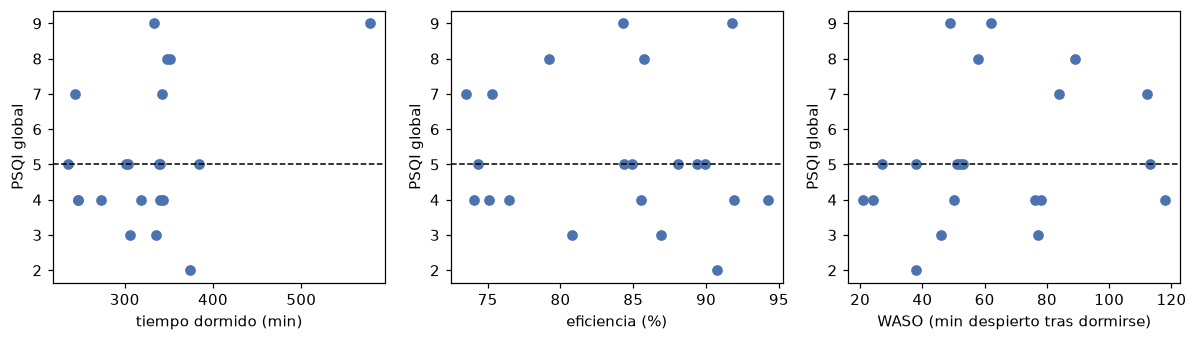

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, v, lab in zip(ax, ["TST_min", "eficiencia", "WASO_min"], ["tiempo dormido (min)", "eficiencia (%)", "WASO (min despierto tras dormirse)"]):
    a.scatter(d[v], d.PSQI, color="#4C72B0"); a.set_xlabel(lab); a.set_ylabel("PSQI global")
    a.axhline(5, color="k", ls="--", lw=1)
plt.tight_layout(); plt.show()

## Lectura de los resultados (exploratorio)

**Xiaomi con datos reales**
- **Las variables del modelo existen en un Xiaomi real**, con dos matices. El **pulso en reposo casi nunca viene** (solo 1 de 4
  usuarios trae la clave), pero el reloj sí graba pulso minuto a minuto y se puede **derivar**: la mediana del pulso durante el
  sueño difiere del valor del dispositivo en solo 1.5 bpm de media (17 días de un solo usuario, poca base). La **SpO2 aparece en
  1 de 4 usuarios**: que el reloj la mida no implica que siempre haya datos.
- **La capa funcionó con el formato real:** los 4 usuarios generaron una salida válida. La capa eligió el perfil según lo que
  había: tres quedaron con el perfil de Xiaomi y el usuario con SpO2 pasó al perfil de Galaxy Watch, que incluye SpO2.
- **Hallazgo importante: la misma variable no significa lo mismo.** Minutos despierto promedia **6.6** en Xiaomi contra **50.6** en
  LifeSnaps, y la eficiencia **98.6 %** contra **94.2 %** (y casi no varía entre noches). Son 4 personas contra 69 y poblaciones
  distintas, así que no es una prueba, pero la diferencia es lo bastante grande como para sospechar que cada marca define
  "despierto" de forma distinta. Un modelo entrenado con Fitbit vería a estos usuarios como durmiendo siempre excelente.
  Esto refuerza la idea de apoyarse en variables robustas entre marcas (tiempo total de sueño, pulso) y **desconfiar de eficiencia y
  minutos despierto** al cruzar marcas. Comprobarlo bien exige una misma persona con dos relojes a la vez.
- **Nada se valida aquí.** La columna `sleep_rating` (0.61 a 0.69 de media) es casi igual en los 4 usuarios y no se sabe cómo se
  obtiene; no permite concluir nada sobre los niveles.

**MMASH (PSQI real)**
- **No se detecta relación entre el PSQI y el sueño medido:** las correlaciones son débiles (|ρ| ≤ 0.26), **todos los intervalos
  incluyen 0** y dos van en dirección contraria a la esperada. Con 21 personas, una sola noche, un PSQI que va de 2 a 9 y un
  actígrafo de investigación, esto **no dice a favor ni en contra**; solo que esta muestra no alcanza.
- **Dato útil para los cortes:** con el PSQI real de estos 22 hombres sanos, 15 quedan en Leve y 7 en Moderado; **ninguno en
  Alto (> 10)**. En una población sana joven, el nivel Alto casi no aparecería.

**Qué implica**
- La derivación de variables (como el pulso en reposo) tiene que ser parte del adaptador de cada marca.
- Antes de fiarse de un modelo entrenado con Fitbit en otras marcas, hace falta comparar las mismas variables en la misma persona.
- Límites: n = 4 y n = 21, sin etiqueta comparable en el Xiaomi, y un solo dataset con PSQI que no es de smartwatches.